In [1]:
from pathlib import Path
import sys
import json
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

cwd = Path.cwd().resolve()
if str(cwd) not in sys.path:
    sys.path.insert(0, str(cwd))

required = ["cartpole.py", "sf3_week1_week2_review.py"]
missing = [f for f in required if not (cwd / f).exists()]
if missing:
    raise FileNotFoundError("Missing required file(s): " + ", ".join(missing))

import sf3_week1_week2_review as sf3
importlib.reload(sf3)

RUN_MODE = 'full'
SEED_DATA = 1
SEED_SPLIT = 123
REG_STRENGTH = 1e-3

if RUN_MODE == "quick":
    n_total = 500
    N_train_values = [100, 200, 300]
    M_values = [10, 20, 40, 80]
    centre_seeds = [0, 1]
    rollout_steps = 80
elif RUN_MODE == "full":
    n_total = 2500
    N_train_values = [300, 600, 1000, 1500]
    M_values = [20, 40, 80, 160, 320]
    centre_seeds = [0, 1, 2, 3, 4]
    rollout_steps = 100
else:
    raise ValueError("RUN_MODE must be 'quick' or 'full'")

paths = sf3.make_paths(Path.cwd())
report_fig_dir = paths.figures / "report_week12"
report_fig_dir.mkdir(parents=True, exist_ok=True)
print("Output root:", paths.root)

Output root: /Users/apple/笔记 Notes/2A Projects/SF3_week_3_4/sf3_w1_w2_repro


In [2]:
dataset_path = paths.data / f"zero_force_{RUN_MODE}_n{n_total}_data{SEED_DATA}_split{SEED_SPLIT}.npz"
if dataset_path.exists():
    print("Loading cached dataset:", dataset_path)
    data = np.load(dataset_path)
    X = data["X_initial"]
    X_next = data["X_next"]
    Y = data["Delta_X"]
    split = sf3.SplitIndices(train=data["train_idx"], val=data["val_idx"], test=data["test_idx"])
else:
    print("Cached dataset not found; rebuilding.")
    X, X_next, Y = sf3.collect_zero_force_dataset(n_total, seed=SEED_DATA)
    split = sf3.make_split_indices(n_total, seed=SEED_SPLIT)
    np.savez(
        dataset_path,
        X_initial=X,
        X_next=X_next,
        Delta_X=Y,
        train_idx=split.train,
        val_idx=split.val,
        test_idx=split.test,
    )

X_train_full, Y_train_full = X[split.train], Y[split.train]
X_val, Y_val = X[split.val], Y[split.val]
X_test, Y_test = X[split.test], Y[split.test]

display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "count": [len(X_train_full), len(X_val), len(X_test)],
}))

Cached dataset not found; rebuilding.


,split,count
0,train,1500
1,validation,500
2,test,500


In [3]:
def load_or_run_sweep(feature_kind):
    summary_path = paths.logs / f"sweep_summary_{feature_kind}_{RUN_MODE}.csv"
    choice_path = paths.logs / f"sweep_choice_{feature_kind}_{RUN_MODE}.json"
    if summary_path.exists() and choice_path.exists():
        summary_df = pd.read_csv(summary_path)
        with open(choice_path) as f:
            chosen = json.load(f)
        return summary_df, chosen

    print(f"Sweep files not found for {feature_kind}; running sweep now.")
    results = sf3.run_m_n_sweep(
        X, Y,
        N_train_values=N_train_values,
        M_values=M_values,
        split_seed=SEED_SPLIT,
        centre_seeds=centre_seeds,
        feature_kind=feature_kind,
        reg_strength=REG_STRENGTH,
    )
    summary = sf3.aggregate_sweep(results)
    chosen = sf3.choose_model_by_one_standard_error(summary)
    summary_df = pd.DataFrame(summary)
    summary_df.to_csv(summary_path, index=False)
    with open(choice_path, "w") as f:
        json.dump(chosen, f, indent=2)
    return summary_df, chosen

summary_raw, chosen_raw = load_or_run_sweep("raw_periodic_kernel")
summary_sc, chosen_sc = load_or_run_sweep("sincos_features")

print("Raw periodic-kernel chosen setting:")
display(pd.DataFrame([chosen_raw]))
print("Sin/cos feature-kernel chosen setting:")
display(pd.DataFrame([chosen_sc]))

Sweep files not found for raw_periodic_kernel; running sweep now.
sweep feature=raw_periodic_kernel N= 300 M=  20 seed=  0 val_std_MSE=0.4638 time=0.00s
sweep feature=raw_periodic_kernel N= 300 M=  20 seed=  1 val_std_MSE=0.4311 time=0.00s
sweep feature=raw_periodic_kernel N= 300 M=  20 seed=  2 val_std_MSE=0.4366 time=0.00s
sweep feature=raw_periodic_kernel N= 300 M=  20 seed=  3 val_std_MSE=0.4468 time=0.00s
sweep feature=raw_periodic_kernel N= 300 M=  20 seed=  4 val_std_MSE=0.4812 time=0.00s
sweep feature=raw_periodic_kernel N= 300 M=  40 seed=  0 val_std_MSE=0.3177 time=0.01s
sweep feature=raw_periodic_kernel N= 300 M=  40 seed=  1 val_std_MSE=0.3233 time=0.01s
sweep feature=raw_periodic_kernel N= 300 M=  40 seed=  2 val_std_MSE=0.2851 time=0.01s
sweep feature=raw_periodic_kernel N= 300 M=  40 seed=  3 val_std_MSE=0.3166 time=0.01s
sweep feature=raw_periodic_kernel N= 300 M=  40 seed=  4 val_std_MSE=0.3239 time=0.00s
sweep feature=raw_periodic_kernel N= 300 M=  80 seed=  0 val_std

,feature_kind,N_train,M,val_std_mse_mean,val_std_mse_std,test_std_mse_mean,elapsed_seconds_mean,num_repeats
0,raw_periodic_kernel,1500,320,0.025635,0.002548,0.027482,0.058762,5


Sin/cos feature-kernel chosen setting:


,feature_kind,N_train,M,val_std_mse_mean,val_std_mse_std,test_std_mse_mean,elapsed_seconds_mean,num_repeats
0,sincos_features,1500,320,0.012119,0.000656,0.012832,0.058309,5


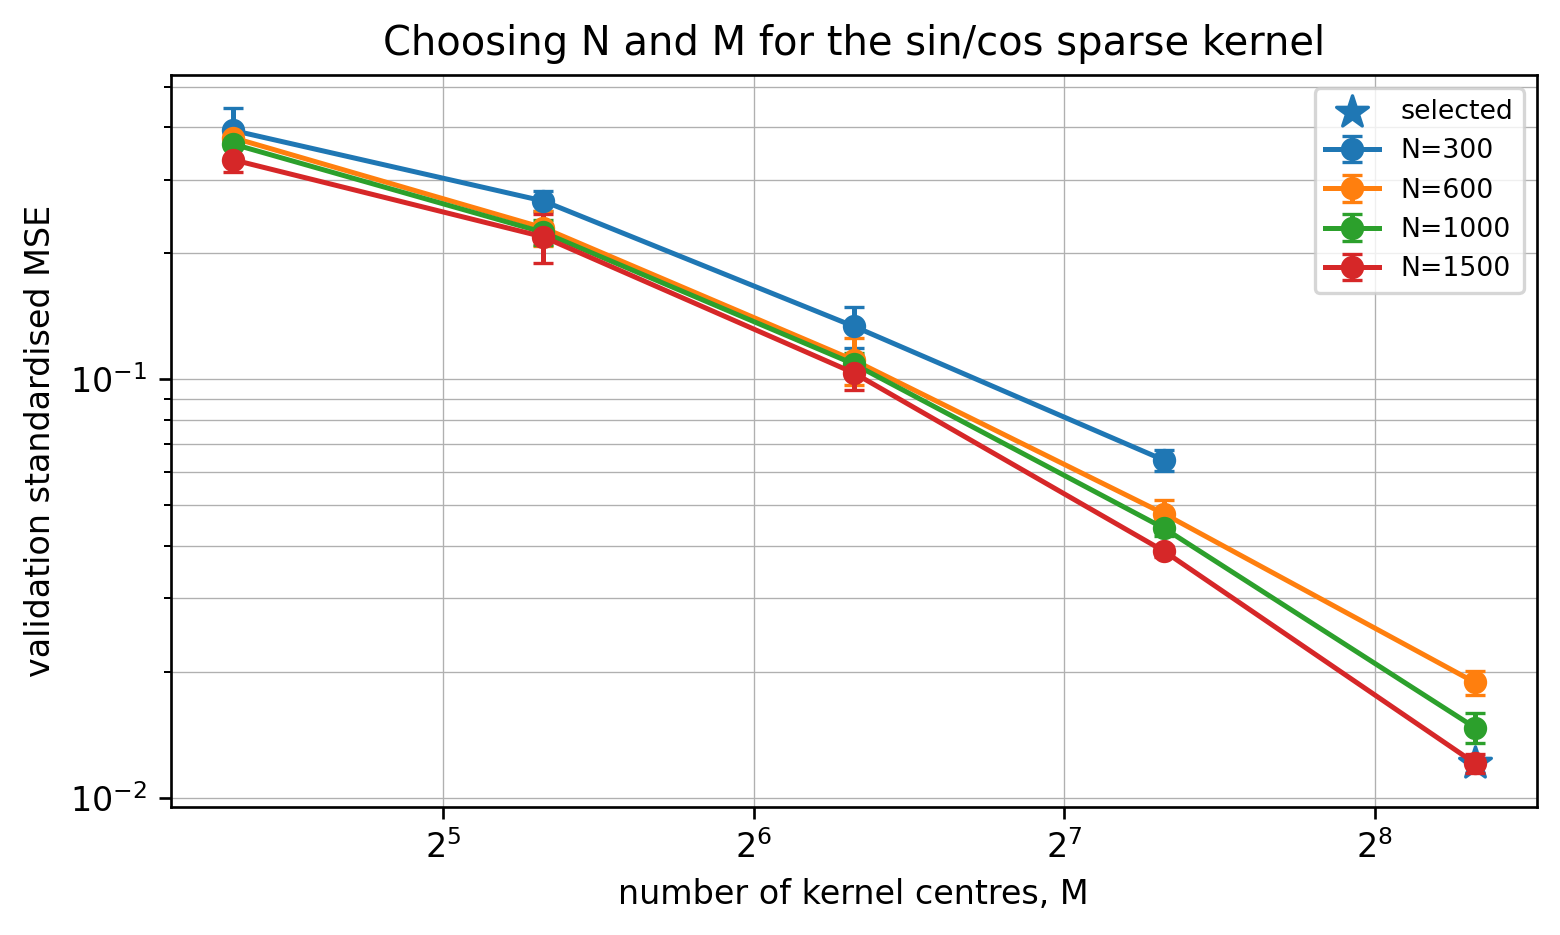

In [4]:
def plot_report_nm(summary_df, chosen, title, filename):
    fig, ax = plt.subplots(figsize=(6.6, 4.0))
    for N in sorted(summary_df["N_train"].unique()):
        rows = summary_df[summary_df["N_train"] == N].sort_values("M")
        ax.errorbar(
            rows["M"],
            rows["val_std_mse_mean"],
            yerr=rows["val_std_mse_std"],
            marker="o",
            capsize=3,
            label=f"N={N}",
        )
    ax.scatter([chosen["M"]], [chosen["val_std_mse_mean"]], s=100, marker="*", label="selected")
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xlabel("number of kernel centres, M")
    ax.set_ylabel("validation standardised MSE")
    ax.set_title(title)
    ax.grid(True, which="both", linewidth=0.4)
    ax.legend(fontsize=8)
    fig.tight_layout()
    out = report_fig_dir / filename
    fig.savefig(out, dpi=240, bbox_inches="tight")
    plt.close(fig)
    return out

nm_fig = plot_report_nm(
    summary_sc,
    chosen_sc,
    "Choosing N and M for the sin/cos sparse kernel",
    f"fig_week12_nm_selection_sincos_{RUN_MODE}.png",
)
display(Image(filename=str(nm_fig)))

In [5]:
print(
    f"Draft text: I selected N={int(chosen_sc['N_train'])} training transitions and "
    f"M={int(chosen_sc['M'])} kernel centres using validation standardised MSE. "
    f"Across repeated random centre choices, the best mean validation error was "
    f"{summary_sc['val_std_mse_mean'].min():.3g}; the selected model had mean validation error "
    f"{chosen_sc['val_std_mse_mean']:.3g}, within one standard deviation of the best, "
    f"while using a smaller number of centres."
)

Draft text: I selected N=1500 training transitions and M=320 kernel centres using validation standardised MSE. Across repeated random centre choices, the best mean validation error was 0.0121; the selected model had mean validation error 0.0121, within one standard deviation of the best, while using a smaller number of centres.


In [6]:
N_final = int(chosen_sc["N_train"])
M_final = int(chosen_sc["M"])
X_train = X_train_full[:N_final]
Y_train = Y_train_full[:N_final]

raw_linear = sf3.fit_linear_delta_model(X_train, Y_train, feature_kind="raw")
sincos_linear = sf3.fit_linear_delta_model(X_train, Y_train, feature_kind="sincos")
sincos_kernel = sf3.fit_sparse_kernel_model(
    X_train,
    Y_train,
    M=M_final,
    reg_strength=REG_STRENGTH,
    seed=456,
    feature_kind="sincos_features",
)

models = {
    "raw linear": lambda Xq: sf3.predict_linear_delta(raw_linear, Xq),
    "sin/cos linear": lambda Xq: sf3.predict_linear_delta(sincos_linear, Xq),
    "sin/cos kernel": lambda Xq: sf3.predict_sparse_kernel_model(sincos_kernel, Xq),
}

metrics = {}
for name, predict in models.items():
    metrics[name] = sf3.evaluate_predictions(
        Y_train, Y_val, Y_test,
        predict(X_train), predict(X_val), predict(X_test),
    )

summary_rows = []
component_rows = []
for name, m in metrics.items():
    summary_rows.append({
        "model": name,
        "validation standardised MSE": m["std_mse_val"],
        "test standardised MSE": m["std_mse_test"],
        "test raw MSE": m["mse_test"],
    })
    for j, target in enumerate(sf3.DELTA_NAMES):
        component_rows.append({
            "model": name,
            "target": target,
            "test raw component MSE": m["mse_component_test"][j],
            "test standardised component MSE": m["std_mse_component_test"][j],
        })

model_summary_df = pd.DataFrame(summary_rows).sort_values("test standardised MSE")
component_df = pd.DataFrame(component_rows)
display(model_summary_df)
display(component_df.pivot(index="target", columns="model", values="test standardised component MSE"))

model_summary_df.to_csv(paths.logs / f"week12_step2_model_summary_{RUN_MODE}.csv", index=False)
component_df.to_csv(paths.logs / f"week12_step2_component_mse_{RUN_MODE}.csv", index=False)

Linear model (raw) Phi shape=(1500, 5), W shape=(5, 4), rank=5
Linear model (sincos) Phi shape=(1500, 6), W shape=(6, 4), rank=6


,model,validation standardised MSE,test standardised MSE,test raw MSE
2,sin/cos kernel,0.012751,0.012576,0.036215
1,sin/cos linear,0.183541,0.209995,0.675814
0,raw linear,0.268602,0.288057,1.001325


model,raw linear,sin/cos kernel,sin/cos linear
target,,,
Delta theta,0.009050,0.007240,0.007050
Delta theta_dot,0.458206,0.015905,0.300669
Delta x,0.004381,0.005103,0.003392
Delta x_dot,0.680589,0.022057,0.528871


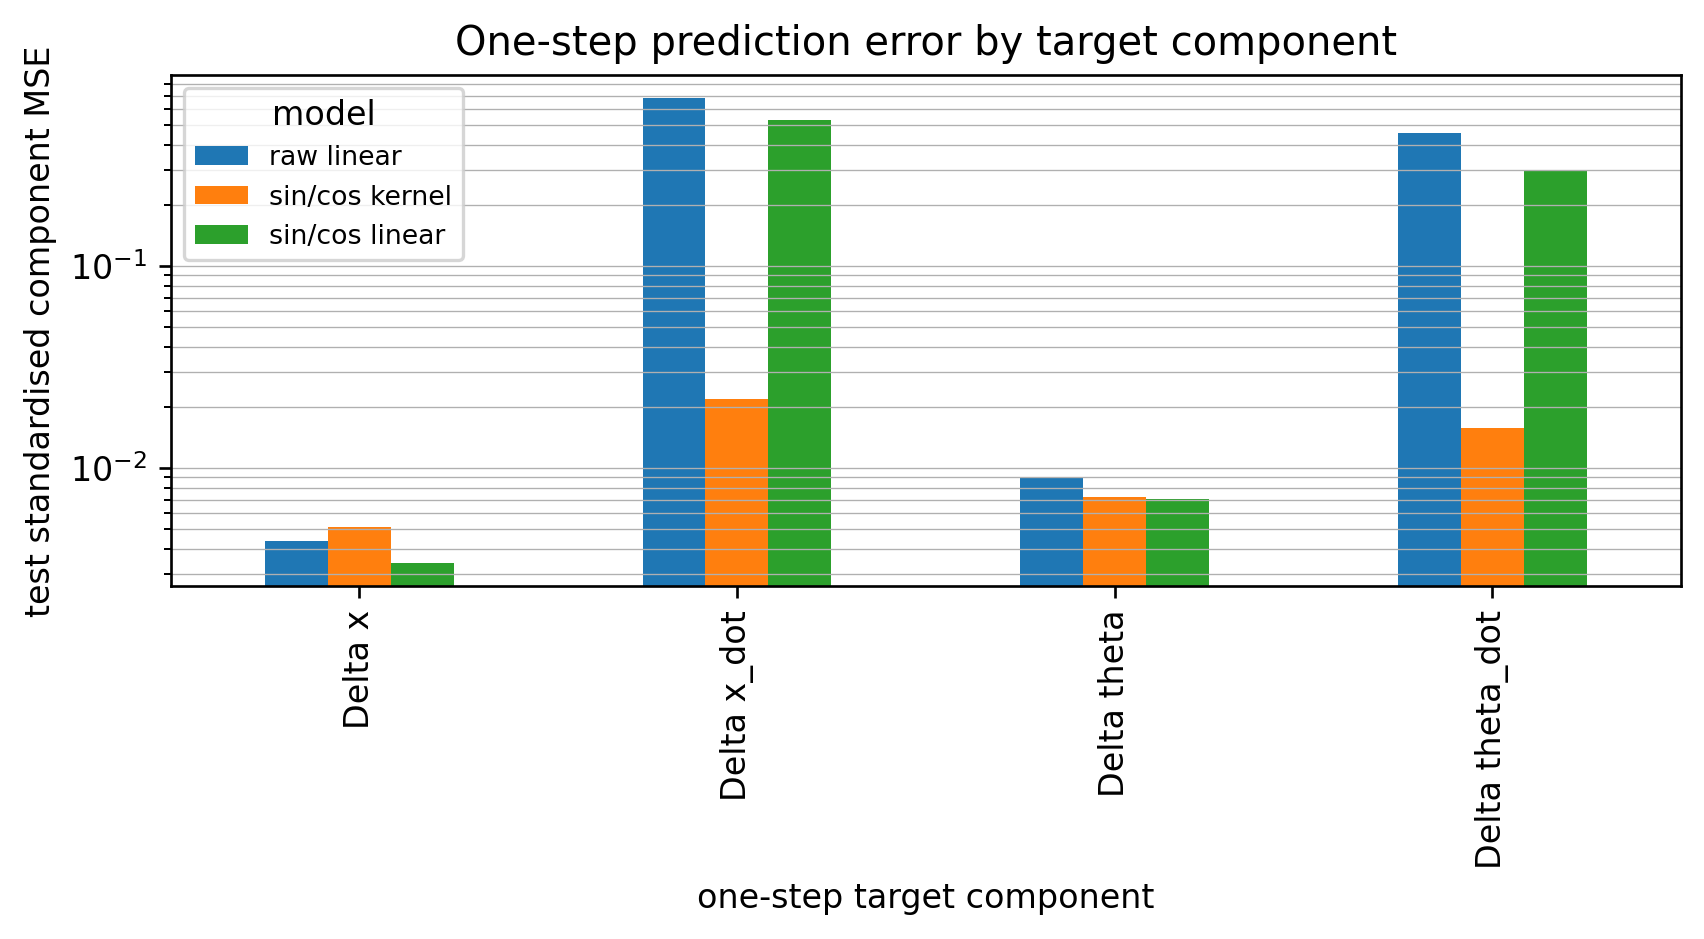

In [7]:
def plot_component_mse(component_df, filename):
    pivot = component_df.pivot(index="target", columns="model", values="test standardised component MSE")
    fig, ax = plt.subplots(figsize=(7.2, 4.0))
    pivot.loc[sf3.DELTA_NAMES].plot(kind="bar", ax=ax)
    ax.set_yscale("log")
    ax.set_xlabel("one-step target component")
    ax.set_ylabel("test standardised component MSE")
    ax.set_title("One-step prediction error by target component")
    ax.grid(True, axis="y", which="both", linewidth=0.4)
    ax.legend(title="model", fontsize=8)
    fig.tight_layout()
    out = report_fig_dir / filename
    fig.savefig(out, dpi=240, bbox_inches="tight")
    plt.close(fig)
    return out

comp_fig = plot_component_mse(component_df, f"fig_week12_component_mse_{RUN_MODE}.png")
display(Image(filename=str(comp_fig)))

In [8]:
rollout_cases = {
    "small downward oscillation": np.array([0.0, 0.0, np.pi, 2.0]),
    "large downward oscillation": np.array([0.0, 0.0, np.pi, 8.0]),
    "full rotation": np.array([0.0, 0.0, np.pi, 15.0]),
    "near upright fall": np.array([0.0, 0.0, 0.2, 0.0]),
}

def horizon_metrics(true_traj, pred_traj, threshold=2.0):
    err = sf3.state_error_norm(true_traj, pred_traj)
    above = np.where(err > threshold)[0]
    if len(above) == 0:
        step = len(err)-1
        exceeded = False
    else:
        step = int(above[0])
        exceeded = True
    return {
        "first step error > threshold": step,
        "time units": 0.1 * step,
        "approx theta cycles": abs(true_traj[step, 2] - true_traj[0, 2])/(2*np.pi),
        "exceeded threshold": exceeded,
        "final error": float(err[-1]),
    }

horizon_rows = []
for case_name, x0 in rollout_cases.items():
    true = sf3.rollout_true(x0, rollout_steps)
    raw_pred = sf3.rollout_linear_model(raw_linear, x0, rollout_steps, remap_raw_theta_input=True)
    sc_pred = sf3.rollout_kernel_model(sincos_kernel, x0, rollout_steps)
    for model_name, pred in [("raw linear", raw_pred), ("sin/cos kernel", sc_pred)]:
        row = {"initial condition": case_name, "model": model_name, "threshold": 2.0}
        row.update(horizon_metrics(true, pred, threshold=2.0))
        horizon_rows.append(row)

horizon_df = pd.DataFrame(horizon_rows)
display(horizon_df)
horizon_df.to_csv(paths.logs / f"week12_step2_rollout_horizon_{RUN_MODE}.csv", index=False)

,initial condition,model,threshold,first step error > threshold,time units,approx theta cycles,exceeded threshold,final error
0,small downward oscillation,raw linear,2.0,1,0.1,0.029253,True,10.187307
1,small downward oscillation,sin/cos kernel,2.0,17,1.7,0.040342,True,2.051815
2,large downward oscillation,raw linear,2.0,1,0.1,0.113134,True,85.619271
3,large downward oscillation,sin/cos kernel,2.0,7,0.7,0.129686,True,6.877867
4,full rotation,raw linear,2.0,1,0.1,0.201965,True,248.040935
5,full rotation,sin/cos kernel,2.0,5,0.5,0.640394,True,11.962874
6,near upright fall,raw linear,2.0,3,0.3,0.084130,True,135.506110
7,near upright fall,sin/cos kernel,2.0,10,1.0,0.895439,True,7.332790


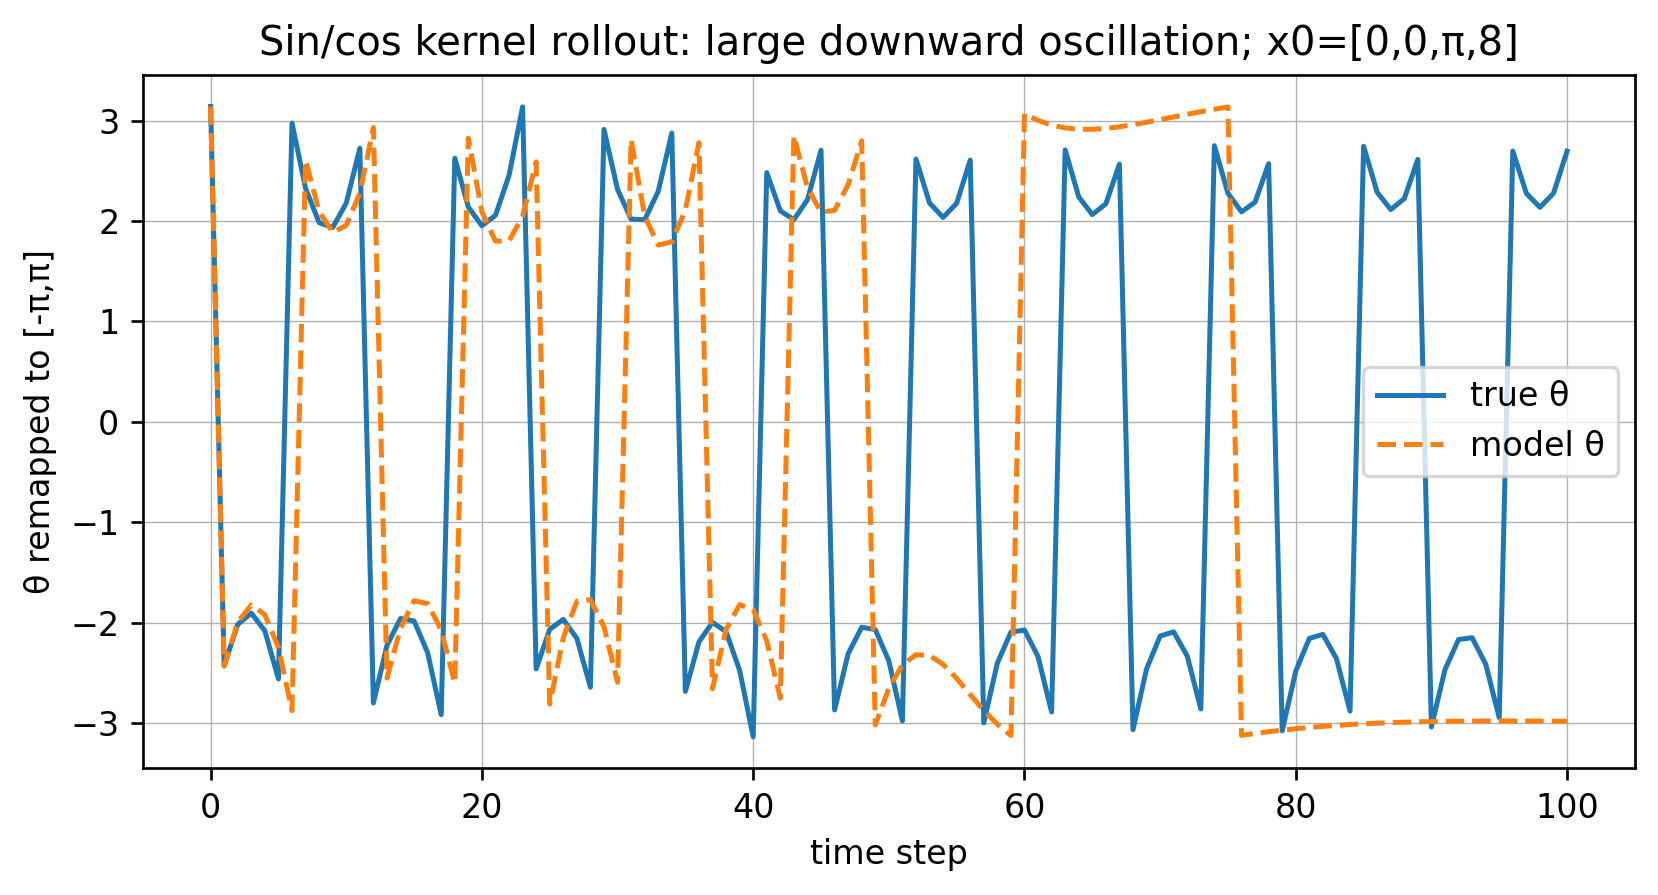

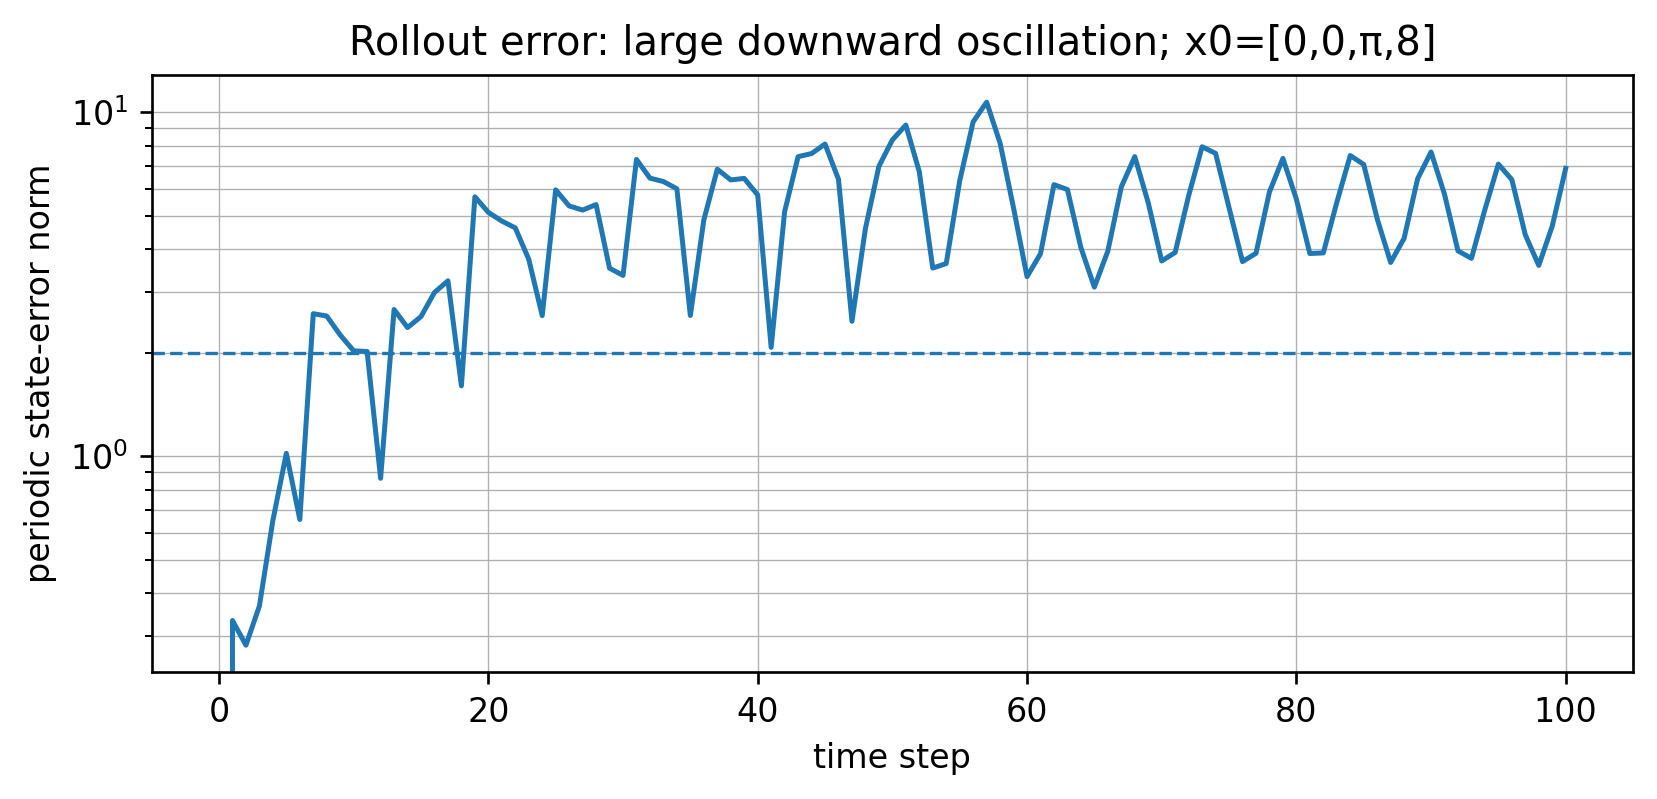

In [9]:
def plot_rollout_case(case_name, x0, filename_prefix):
    true = sf3.rollout_true(x0, rollout_steps)
    pred = sf3.rollout_kernel_model(sincos_kernel, x0, rollout_steps)
    t = np.arange(rollout_steps+1)
    true_plot = true.copy()
    pred_plot = pred.copy()
    true_plot[:, 2] = sf3.remap_angle_array(true_plot[:, 2])
    pred_plot[:, 2] = sf3.remap_angle_array(pred_plot[:, 2])
    err = sf3.state_error_norm(true, pred)

    fig, ax = plt.subplots(figsize=(7.0, 3.8))
    ax.plot(t, true_plot[:, 2], label="true θ")
    ax.plot(t, pred_plot[:, 2], linestyle="--", label="model θ")
    ax.set_xlabel("time step")
    ax.set_ylabel("θ remapped to [-π,π]")
    ax.set_title(f"Sin/cos kernel rollout: {case_name}")
    ax.grid(True, linewidth=0.4)
    ax.legend()
    fig.tight_layout()
    angle_out = report_fig_dir / f"{filename_prefix}_theta_{RUN_MODE}.png"
    fig.savefig(angle_out, dpi=240, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(7.0, 3.4))
    ax.plot(t, err)
    ax.axhline(2.0, linestyle="--", linewidth=1.0)
    ax.set_yscale("log")
    ax.set_xlabel("time step")
    ax.set_ylabel("periodic state-error norm")
    ax.set_title(f"Rollout error: {case_name}")
    ax.grid(True, which="both", linewidth=0.4)
    fig.tight_layout()
    error_out = report_fig_dir / f"{filename_prefix}_error_{RUN_MODE}.png"
    fig.savefig(error_out, dpi=240, bbox_inches="tight")
    plt.close(fig)
    return angle_out, error_out

angle_fig, error_fig = plot_rollout_case(
    "large downward oscillation; x0=[0,0,π,8]",
    rollout_cases["large downward oscillation"],
    "fig_week12_rollout_large_downward",
)
display(Image(filename=str(angle_fig)))
display(Image(filename=str(error_fig)))

In [10]:
selected_horizon = horizon_df[
    (horizon_df["initial condition"] == "large downward oscillation") &
    (horizon_df["model"] == "sin/cos kernel")
].iloc[0]

captions = {
    "N/M selection": (
        f"Validation standardised MSE for the sin/cos sparse-kernel dynamics model as a function "
        f"of training transitions N and kernel centres M. Error bars show variation over random centre "
        f"seeds. The selected setting was N={int(chosen_sc['N_train'])}, M={int(chosen_sc['M'])}, chosen "
        f"by a one-standard-error rule to avoid using a larger basis after validation error had plateaued."
    ),
    "Component MSE": (
        "Component-wise one-step test error for Δx, Δx_dot, Δθ and Δθ_dot. "
        "Errors are standardised by the training-set standard deviation of each target component, so the "
        "large-magnitude acceleration components do not dominate the comparison."
    ),
    "Rollout": (
        f"Recursive rollout from initial condition [x, x_dot, θ, θ_dot]=[0,0,π,8] under zero force. "
        f"The sin/cos kernel predicts ΔX and feeds its own prediction back as the next input. "
        f"Using a periodic state-error threshold of 2.0, agreement lasted until step "
        f"{int(selected_horizon['first step error > threshold'])}, approximately "
        f"{selected_horizon['time units']:.1f} time units and "
        f"{selected_horizon['approx theta cycles']:.2f} raw-theta cycles."
    ),
}

for name, cap in captions.items():
    print(f"\n{name} caption draft:\n{cap}")

with open(paths.logs / f"week12_step2_caption_drafts_{RUN_MODE}.json", "w") as f:
    json.dump(captions, f, indent=2)


N/M selection caption draft:
Validation standardised MSE for the sin/cos sparse-kernel dynamics model as a function of training transitions N and kernel centres M. Error bars show variation over random centre seeds. The selected setting was N=1500, M=320, chosen by a one-standard-error rule to avoid using a larger basis after validation error had plateaued.

Component MSE caption draft:
Component-wise one-step test error for Δx, Δx_dot, Δθ and Δθ_dot. Errors are standardised by the training-set standard deviation of each target component, so the large-magnitude acceleration components do not dominate the comparison.

Rollout caption draft:
Recursive rollout from initial condition [x, x_dot, θ, θ_dot]=[0,0,π,8] under zero force. The sin/cos kernel predicts ΔX and feeds its own prediction back as the next input. Using a periodic state-error threshold of 2.0, agreement lasted until step 7, approximately 0.7 time units and 0.13 raw-theta cycles.
